# Workflow for downloading multiple CORDEX variables for Sierra Leone

In [1]:
import json
import pandas as pd
import geopandas as gpd
import xarray as xr
from dhis2eo.data.cds import cordex
from dhis2_client import DHIS2Client
from dhis2eo.integrations.pandas import dataframe_to_dhis2_json

In [2]:
# Params
DHIS2_BASE_URL = 'https://climate.im.dhis2.org/climate-projections-42'
DHIS2_USERNAME = 'admin'
DHIS2_PASSWORD = 'district'
DHIS2_ORG_UNIT_LEVEL = 2

In [5]:
# Connect
client = DHIS2Client(
    base_url=DHIS2_BASE_URL,
    username=DHIS2_USERNAME,
    password=DHIS2_PASSWORD,
)
info = client.get_system_info()

# Check if everything is working.
# You should see your current DHIS2 version info.
print("Current DHIS2 version:", info["version"])

### Get org units GeoJSON from DHIS2
org_units_geojson = client.get_org_units_geojson(level=DHIS2_ORG_UNIT_LEVEL)

# Convert GeoJSON to geopandas
org_units = gpd.read_file(json.dumps(org_units_geojson))
org_units

Current DHIS2 version: 2.42.3.1


,id,code,name,level,parent,parentGraph,groups,geometry
0,O6uvpzGd5pu,OU_264,Bo,2,ImspTQPwCqd,ImspTQPwCqd,"[w1Atoz18PCL, jqBqIXoXpfy]","POLYGON ((-11.5914 8.4875, -11.5906 8.4769, -1..."
1,fdc6uOvgoji,OU_193190,Bombali,2,ImspTQPwCqd,ImspTQPwCqd,"[w1Atoz18PCL, J40PpdN4Wkk, GGghZsfu7qV]","POLYGON ((-11.8091 9.2032, -11.8102 9.1944, -1..."
2,lc3eMKXaEfw,OU_197385,Bonthe,2,ImspTQPwCqd,ImspTQPwCqd,"[w1Atoz18PCL, jqBqIXoXpfy, GGghZsfu7qV]","MULTIPOLYGON (((-12.5568 7.3832, -12.5574 7.38..."
3,jUb8gELQApl,OU_204856,Kailahun,2,ImspTQPwCqd,ImspTQPwCqd,"[w1Atoz18PCL, GGghZsfu7qV, nlX2VoouN63]","POLYGON ((-10.7972 7.5866, -10.8002 7.5878, -1..."
4,PMa2VCrupOd,OU_211212,Kambia,2,ImspTQPwCqd,ImspTQPwCqd,"[w1Atoz18PCL, GGghZsfu7qV, b0EsAxm8Nge, nlX2Vo...","MULTIPOLYGON (((-13.1349 8.8471, -13.1343 8.84..."
5,kJq2mPyFEHo,OU_222616,Kenema,2,ImspTQPwCqd,ImspTQPwCqd,"[f25dqv3Y7Z0, w1Atoz18PCL]","POLYGON ((-11.3596 8.5317, -11.3513 8.5234, -1..."
6,qhqAxPSTUXp,OU_226213,Koinadugu,2,ImspTQPwCqd,ImspTQPwCqd,"[f25dqv3Y7Z0, w1Atoz18PCL, J40PpdN4Wkk]","POLYGON ((-10.585 9.0434, -10.5877 9.0432, -10..."
7,Vth0fbpFcsO,OU_233310,Kono,2,ImspTQPwCqd,ImspTQPwCqd,"[f25dqv3Y7Z0, w1Atoz18PCL, J40PpdN4Wkk]","POLYGON ((-10.585 9.0434, -10.5848 9.0432, -10..."
8,jmIPBj66vD6,OU_246990,Moyamba,2,ImspTQPwCqd,ImspTQPwCqd,"[f25dqv3Y7Z0, w1Atoz18PCL, jqBqIXoXpfy]","MULTIPOLYGON (((-12.6351 7.6613, -12.6346 7.66..."
9,TEQlaapDQoK,OU_254945,Port Loko,2,ImspTQPwCqd,ImspTQPwCqd,"[f25dqv3Y7Z0, w1Atoz18PCL, b0EsAxm8Nge]","MULTIPOLYGON (((-13.119 8.4718, -13.1174 8.470..."


## Download and save to reduced file format

In [6]:
# begin
start_year = 2021
end_year = 2095
dirname = '../test_outputs/cordex/sierra_leone'
variables = [
    "mean_precipitation_flux",
    "2m_air_temperature",
    "minimum_2m_temperature_in_the_last_24_hours",
    "maximum_2m_temperature_in_the_last_24_hours"
]
region = 'africa'
bbox = list(map(float, org_units.total_bounds))
resolution = '0_22_degree_x_0_22_degree'
scenarios = ['rcp_8_5']

import logging
logging.basicConfig(level='INFO')

files = []
for scenario in scenarios:
    print('# Scenario', scenario)
    for var,shortvar in zip(variables, ['pr', 'tas', 'tasmin', 'tasmax']):
        print(f'## Variable: {shortvar} {var}')
        prefix = f'cordex_{shortvar}'
        scenario_models = cordex.MODELS[region][resolution][scenario]
        subfiles = cordex.daily.download(start_year, end_year, region, dirname, prefix, [var], scenario, resolution, 
                                        scenario_models, clean=True, bbox=bbox, overwrite=False)
        print('-->', subfiles)
        files.extend(subfiles)

files

# Scenario rcp_8_5
## Variable: pr mean_precipitation_flux


INFO:dhis2eo.data.cds.cordex.daily:GCM model cccma_canesm2
INFO:dhis2eo.data.cds.cordex.daily:RCM model cccma_canrcm4
INFO:dhis2eo.data.cds.cordex.daily:Ensemble r1i1p1
INFO:dhis2eo.data.cds.cordex.daily:Years 2021 to 2025
INFO:dhis2eo.data.cds.cordex.daily:File already exists, reusing from cache C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\sierra_leone\cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2021-2025.nc
INFO:dhis2eo.data.cds.cordex.daily:Years 2026 to 2030
INFO:dhis2eo.data.cds.cordex.daily:File already exists, reusing from cache C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\sierra_leone\cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2026-2030.nc
INFO:dhis2eo.data.cds.cordex.daily:Years 2031 to 2035
INFO:dhis2eo.data.cds.cordex.daily:File already exists, reusing from cache C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\sierra_leone\cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2031-2035.nc
INF

1174e1207c76a5988a3c3412607dfc6e.zip:   0%|          | 0.00/922M [00:00<?, ?B/s]

INFO:dhis2eo.data.cds.cordex.daily:Converting longitude coordinates from 0 to 360, to -180 to 180
INFO:dhis2eo.data.cds.cordex.daily:Cleaning and optimizing file
INFO:dhis2eo.data.cds.cordex.daily:Cropping to bbox
INFO:dhis2eo.data.cds.cordex.daily:Finished downloading to C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\sierra_leone\cordex_pr_rcp-8-5_mohc-hadgem2-es_gerics-remo2015_r1i1p1_2066-2070.nc
INFO:dhis2eo.data.cds.cordex.daily:All 1 downloads completed


--> [WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2021-2025.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2026-2030.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2031-2035.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2036-2040.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2041-2045.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2046-2050.nc'), WindowsPath('C:/U

...

INFO:dhis2eo.data.cds.cordex.daily:GCM model cccma_canesm2
INFO:dhis2eo.data.cds.cordex.daily:RCM model cccma_canrcm4
INFO:dhis2eo.data.cds.cordex.daily:Ensemble r1i1p1
INFO:dhis2eo.data.cds.cordex.daily:Years 2021 to 2025
INFO:dhis2eo.data.cds.cordex.daily:File already exists, reusing from cache C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\sierra_leone\cordex_tasmin_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2021-2025.nc
INFO:dhis2eo.data.cds.cordex.daily:Years 2026 to 2030
INFO:dhis2eo.data.cds.cordex.daily:File already exists, reusing from cache C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\sierra_leone\cordex_tasmin_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2026-2030.nc
INFO:dhis2eo.data.cds.cordex.daily:Years 2031 to 2035
INFO:dhis2eo.data.cds.cordex.daily:File already exists, reusing from cache C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\sierra_leone\cordex_tasmin_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2031

--> [WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_tasmin_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2021-2025.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_tasmin_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2026-2030.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_tasmin_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2031-2035.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_tasmin_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2036-2040.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_tasmin_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2041-2045.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_tasmin_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2046-2050

INFO:dhis2eo.data.cds.cordex.daily:GCM model cccma_canesm2
INFO:dhis2eo.data.cds.cordex.daily:RCM model cccma_canrcm4
INFO:dhis2eo.data.cds.cordex.daily:Ensemble r1i1p1
INFO:dhis2eo.data.cds.cordex.daily:Years 2021 to 2025
INFO:dhis2eo.data.cds.cordex.daily:File already exists, reusing from cache C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\sierra_leone\cordex_tasmax_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2021-2025.nc
INFO:dhis2eo.data.cds.cordex.daily:Years 2026 to 2030
INFO:dhis2eo.data.cds.cordex.daily:File already exists, reusing from cache C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\sierra_leone\cordex_tasmax_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2026-2030.nc
INFO:dhis2eo.data.cds.cordex.daily:Years 2031 to 2035
INFO:dhis2eo.data.cds.cordex.daily:File already exists, reusing from cache C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\sierra_leone\cordex_tasmax_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2031

--> [WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_tasmax_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2021-2025.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_tasmax_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2026-2030.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_tasmax_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2031-2035.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_tasmax_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2036-2040.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_tasmax_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2041-2045.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_tasmax_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2046-2050

[WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2021-2025.nc'),
 WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2026-2030.nc'),
 WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2031-2035.nc'),
 WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2036-2040.nc'),
 WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2041-2045.nc'),
 WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/sierra_leone/cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2046-2050.nc'),
 WindowsPath('C:

In [7]:
# generate reference cordex xarray ds
import cordex as cx
d = cx.domain('AFR-22')

# get bbox
xmin,ymin,xmax,ymax = map(float, org_units.total_bounds)

# crop to org units
xres = abs(d.lon.max() - d.lon.min()) / len(d.rlon)
yres = abs(d.lat.max() - d.lat.min()) / len(d.rlat)
mask = (
    (d.lat >= (ymin-yres)) & (d.lat <= (ymax+yres)) &
    (d.lon >= (xmin-xres))  & (d.lon <= (xmax+xres))
).compute()
d = d.where(mask, drop=True).compute()

print(d.lon.sizes, d.lon.values.min(), d.lon.values.max())
print(d.lat.sizes, d.lat.values.min(), d.lat.values.max())

cordex_grid = d
cordex_grid

Frozen({'rlat': 16, 'rlon': 15}) -13.309999999999935 -10.230000000000025
Frozen({'rlat': 16, 'rlon': 15}) 6.7100000000000035 10.010000000000003


<xarray.Dataset> Size: 6kB
Dimensions:                     (rlat: 16, rlon: 15)
Coordinates:
  * rlat                        (rlat) float64 128B 6.71 6.93 ... 9.79 10.01
  * rlon                        (rlon) float64 120B -13.31 -13.09 ... -10.23
    lon                         (rlat, rlon) float64 2kB -13.31 ... -10.23
    lat                         (rlat, rlon) float64 2kB 6.71 6.71 ... 10.01
Data variables:
    rotated_latitude_longitude  (rlat, rlon) float64 2kB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    CORDEX_domain:  AFR-22

In [ ]:
# collect and prep files before concat
datasets = []
#subfiles = [f for f in files if str(f).endswith('2021-2025.nc')]
for fil in files:

    # open dataset
    print('-------->', fil)
    d = xr.open_dataset(fil) #, chunks={"time": 360}) #, "rlat": 100, "rlon": 100})
    if hasattr(d, 'Lambert_Conformal'):
        print('Skipping lambert projection!')
        continue
    # print(d.lon.sizes, d.lon.values.min(), d.lon.values.max())
    # print(d.lat.sizes, d.lat.values.min(), d.lat.values.max())

    # snap to reference grid
    d = d.reindex(
        rlat=cordex_grid.rlat,
        rlon=cordex_grid.rlon,
        method="nearest",
        #tolerance=0.12,
    )
    d = d.assign_coords({'lon': cordex_grid.lon, 'lat': cordex_grid.lat})

    # time interpolate to same calendar
    import numpy as np
    if hasattr(d.indexes["time"], 'to_datetimeindex'):
        # NOTE: still a problem that it cant interpolate beyond the last date
        # ...eg if last input date was 30 dec, it cant interpolate to 31 dec (last year only)
        # ...but will have to just be ok since we should aggregate to weekly or monthly anyway
        print(f'interpolating from {d.time.to_index().calendar} to gregorian')
        # overwrite input hour
        d = d.assign_coords(time=[v.replace(hour=0) for v in d.time.values])
        # enforce first day of gregorian year
        d_start = d.time.values[0]
        np_start = pd.Timestamp(year=d_start.year, month=d_start.month, day=1).to_datetime64()
        # enforce last day of gregorian year
        d_end   = d.time.values[-1]
        np_end = pd.Timestamp(year=d_end.year, month=d_end.month, day=31).to_datetime64()
        # create numpy date range
        target_times = np.arange(np_start, np_end + np.timedelta64(1, 'D'), dtype='datetime64[D]')
        # overwrite output hour (should be same as input i think...)
        target_times = target_times + np.timedelta64(0, 'h')
        # convert to pandas range
        target_times = pd.DatetimeIndex([
            pd.Timestamp(t) for t in target_times
        ])
        # interpolate daily values to gregorian
        #print(d.isel(time=0).pr.mean())
        #timeslice = slice(35)
        #timeslice = slice(-35, None)
        #timeslice = slice(345, 370)
        #d.pr.isel(time=timeslice).plot(col='time', col_wrap=7)
        d = d.interp_calendar(target_times)
        #print(d.isel(time=0).pr.mean())
        #d.pr.isel(time=timeslice).plot(col='time', col_wrap=7)
        #fdsf

    # ensure all use same daily numpy datetime
    # important to avoid merge error later
    d = d.assign_coords(time=d.time.values.astype('datetime64[D]'))
    
    # make gcm-rcm-member combo a dimension that we can select on after concat
    gcm = d.model_id
    rcm = d.driving_model_id
    member = d.driving_model_ensemble_member
    ensemble_id = f'{gcm}__{rcm}__{member}'
    d = d.assign_coords(ensemble=ensemble_id).expand_dims("ensemble")
    
    # make scenario a dimension that we can select on after concat
    scenario_id = d.experiment_id
    d = d.assign_coords(scenario=scenario_id).expand_dims("scenario")
    
    # add to list
    datasets.append(d)

--------> C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\sierra_leone\cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2021-2025.nc
interpolating from noleap to gregorian
--------> C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\sierra_leone\cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2026-2030.nc
interpolating from noleap to gregorian
--------> C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\sierra_leone\cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2031-2035.nc
interpolating from noleap to gregorian
--------> C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\sierra_leone\cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2036-2040.nc
interpolating from noleap to gregorian
--------> C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\sierra_leone\cordex_pr_rcp-8-5_cccma-canesm2_cccma-canrcm4_r1i1p1_2041-2045.nc
interpolating from noleap to gregorian
--------> C:\Users\k

In [ ]:
# concat
ds = xr.combine_by_coords(
    #datasets,
    [x.assign_coords(time=x.time.values.astype('datetime64[D]')) for x in datasets], # TODO: Remove
    #sorted([x.convert_calendar('noleap') for x in datasets if hasattr(x, 'pr')], key=lambda x: x.time.values[0]),
    #[d.sortby('time') for d in datasets],
    #sorted(datasets, key=lambda x: x.time.values[0]),
    #sorted([x for x in datasets if hasattr(x, 'pr')], key=lambda x: x.time.values[0]),
    compat='override',
    coords='minimal',
    combine_attrs="override",
)
ds

<xarray.Dataset> Size: 1GB
Dimensions:       (scenario: 1, ensemble: 7, time: 27393, rlat: 16, rlon: 15)
Coordinates:
  * scenario      (scenario) <U5 20B 'rcp85'
  * ensemble      (ensemble) <U47 1kB 'CCCma-CanRCM4__CCCma-CanESM2__r1i1p1' ...
  * time          (time) datetime64[s] 219kB 2021-01-01 ... 2095-12-31
  * rlat          (rlat) float64 128B 6.71 6.93 7.15 7.37 ... 9.57 9.79 10.01
  * rlon          (rlon) float64 120B -13.31 -13.09 -12.87 ... -10.45 -10.23
    rotated_pole  |S1 1B ...
    lon           (rlat, rlon) float64 2kB -13.31 -13.09 ... -10.45 -10.23
    lat           (rlat, rlon) float64 2kB 6.71 6.71 6.71 ... 10.01 10.01 10.01
    height        float64 8B ...
Data variables:
    pr            (scenario, ensemble, time, rlat, rlon) float64 368MB 1.995e...
    tas           (scenario, ensemble, time, rlat, rlon) float64 368MB 301.7 ...
    tasmin        (scenario, ensemble, time, rlat, rlon) float64 368MB 301.5 ...
    tasmax        (scenario, ensemble, time, rlat, rlon) float64 368MB 301.8 ...
Attributes: (12/26)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    contact:                        cccma_info@ec.gc.ca
    Conventions:                    CF-1.4
    experiment:                     RCP8.5 run driven by CCCma-CanESM2 
    ...                             ...
    history:                        created: 2012-12-22 23:44:26 by rcm2nc
    data_licence:                   1) GRANT OF LICENCE - The Government of C...
    creation_date:                  2012-12-22-T23:17:00Z
    c3s_comment:                    This data has been published at ESGF with...
    tracking_id:                    hdl:21.14103/170add06-db8c-4106-95a2-0626...
    c3s_disclaimer:                 This data has been curated and prepared i...

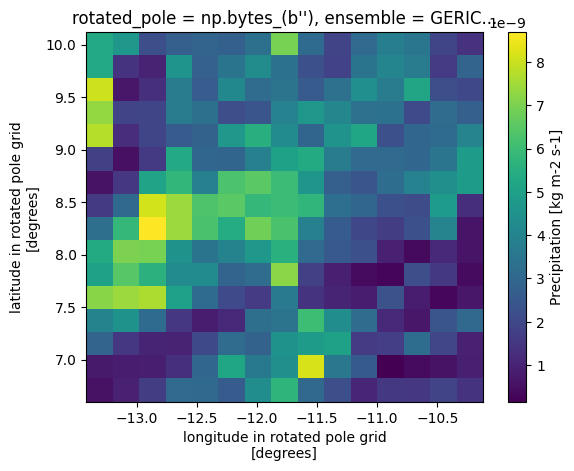

In [201]:
ds.isel(scenario=0, ensemble=5, time=0)['pr'].plot()

In [200]:
# convert units and maybe aggregate to months

# convert precipitation flux per second (kg m-2 s-1) to daily
# 1 kg/m2 of water is equivalent to 1mm of liquid water depth
ds['pr'] *= 86400 # seconds per day

# convert kelvin to celsius
ds['tas'] -= 272.15
ds['tasmin'] -= 272.15
ds['tasmax'] -= 272.15

In [203]:
# aggregate to months to avoid calendar trouble and daily is mostly noise
monthly = xr.Dataset({
    "pr_sum": ds['pr'].resample(time="MS", skipna=True).sum(dim="time"),
    "tas_mean": ds['tas'].resample(time="MS", skipna=True).mean(dim="time"),
    "tasmin_mean": ds['tasmin'].resample(time="MS", skipna=True).mean(dim="time"),
    "tasmin_min": ds['tasmin'].resample(time="MS", skipna=True).min(dim="time"),
    "tasmax_mean": ds['tasmax'].resample(time="MS", skipna=True).mean(dim="time"),
    "tasmax_max": ds['tasmax'].resample(time="MS", skipna=True).max(dim="time"),
})
monthly

<xarray.Dataset> Size: 73MB
Dimensions:       (rlon: 15, rlat: 16, ensemble: 7, scenario: 1, time: 900)
Coordinates:
  * rlon          (rlon) float64 120B -13.31 -13.09 -12.87 ... -10.45 -10.23
  * rlat          (rlat) float64 128B 6.71 6.93 7.15 7.37 ... 9.57 9.79 10.01
  * ensemble      (ensemble) <U47 1kB 'CCCma-CanRCM4__CCCma-CanESM2__r1i1p1' ...
  * scenario      (scenario) <U5 20B 'rcp85'
  * time          (time) datetime64[s] 7kB 2021-01-01 2021-02-01 ... 2095-12-01
    rotated_pole  |S1 1B b''
    lon           (rlat, rlon) float64 2kB -13.31 -13.09 ... -10.45 -10.23
    lat           (rlat, rlon) float64 2kB 6.71 6.71 6.71 ... 10.01 10.01 10.01
    height        float64 8B 2.0
Data variables:
    pr_sum        (scenario, ensemble, time, rlat, rlon) float64 12MB 10.05 ....
    tas_mean      (scenario, ensemble, time, rlat, rlon) float64 12MB 29.72 ....
    tasmin_mean   (scenario, ensemble, time, rlat, rlon) float64 12MB 29.59 ....
    tasmin_min    (scenario, ensemble, time, rlat, rlon) float64 12MB 29.23 ....
    tasmax_mean   (scenario, ensemble, time, rlat, rlon) float64 12MB 29.82 ....
    tasmax_max    (scenario, ensemble, time, rlat, rlon) float64 12MB 30.02 ....

In [204]:
# save to disk so can reuse later
monthly.to_netcdf('../test_outputs/cordex/sierra_leone/cordex_multivar_sierra_leone.nc')